In [1]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

/u/sebono/miniconda3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [696]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

Loaded model: gpt2


In [697]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [698]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [699]:
from compute_perplexity_dims import compute_p1, compute_p2, compute_p3
from utils import swap_speaker_tokens_with_metadata, get_shuffled_dialog_data, reorder_tokens

In [700]:
import numpy as np
import re
import pandas as pd

In [701]:
tri_pilot_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/triadic-pilot/conversations.csv")
tri_pilot_df

,file_name,file_content
0,p08_s03,<SPK1> Oh. Yay. It's story time. <SPK2> Hello....
1,p10_s02,<SPK3> Hello. <SPK2> Hi. <SPK0> Hi. <SPK3> You...
2,p09_s04,<SPK2> I will now turn on a start audio video ...
3,p09_s05,"<SPK0> Uh, and how did they turned on? <SPK3> ..."
4,p12_s02,<SPK2> Hello. <SPK1> Hello. <SPK0> Hello. <SPK...
...,...,...
67,p03_s05,<SPK2> [Foreign Language 00:00:57] <SPK1> [For...
68,p11_s05,<SPK0> (laughs) So funny. <SPK2> Hello. <SPK1>...
69,p12_s00,"<SPK2> Hello. <SPK1> Hi. Hi, Jibo. <SPK0> Hi, ..."
70,p10_s00,<SPK2> Hello. I am now on story time mode. My ...


In [702]:
dialog = tri_pilot_df.iloc[0]['file_content']
file_name = tri_pilot_df.iloc[0]['file_name']

In [703]:
file_name

'p08_s03'

In [314]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

Token indices sequence length is longer than the specified maximum sequence length for this model (7322 > 1024). Running this sequence through the model will result in indexing errors


In [315]:
assert len(matches) == len(dialog_lines)

In [156]:
p1_triadic = compute_p1(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

  1%|█▏                                                                                                                                                                             | 52/7821 [00:02<06:48, 19.03it/s]

KeyboardInterrupt



In [ ]:
p2_triadic = compute_p2(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
p3_triadic = compute_p3(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [157]:
from utils import correlation_heatmap

In [704]:
#file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
#all_data = pd.DataFrame({"p1":all_data_filtered['p1'],"p2":all_data_filtered['p2'],"p3":all_data_filtered['p3'], "dim1_pca":dim1_pca, "p2":p2, "p3":p3})
#all_data.to_csv(file_name_sample, index=False)

In [705]:
file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
all_data = pd.read_csv(file_name_sample)
all_data.head()

,p1,p2,p3,dim1_pca,dim2_pca,dim3_pca
0,8.689340,8.689340,5.679613,8.291113,4.670045,3.926611
1,8.689340,8.689340,4.582078,8.306746,4.921624,2.858412
2,6.234131,7.461735,3.234659,5.643453,4.673452,1.376562
3,4.770369,6.564613,2.018494,4.020592,4.464434,0.054018
4,3.035107,5.682234,1.711300,2.125422,4.127262,-0.368758


In [706]:
from utils import correlation_heatmap, correlation_heatmap, compute_dominance_per_spk, rolling_kde_heatmap_with_turns, remove_match_prefix_ppl, compute_graph_perplexity, display_turns_colored_by_kde

In [707]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [708]:
fig_corr

In [709]:
from utils import remove_match_prefix_ppl, display_colored_sentences, extract_tokens_and_ppls_by_turn_indices

In [710]:
filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_tokens_p1)

In [711]:
filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_tokens_p2)

In [712]:
filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_tokens_p3)

In [713]:
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)

assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

In [714]:
# BEFORE
all_data_filtered_filtered = pd.DataFrame({"p1":filtered_ppl_p1, "p2":filtered_ppl_p2, "p3":filtered_ppl_p3})
col_1 = ["p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered_filtered)

In [715]:
fig_corr

In [716]:
# Get turn indices for SPK0 (kid)
start_turn=0
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p2)[start_turn:end_turn] == '<SPK0>')[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spk0, filtered_ppl_p2_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p2, filtered_ppl_p2
)

In [717]:
# Get turn indices for SPK0 (kid)
start_turn=0
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] == '<SPK0>')[0]

# Get filtered tokens and PPLs
filtered_tokens_p3_spk0, filtered_ppl_p3_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p3, filtered_ppl_p3
)

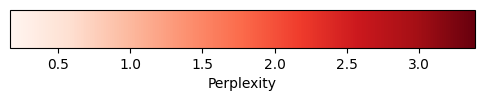

In [718]:
display_colored_sentences(filtered_tokens_p2_spk0, filtered_ppl_p2_spk0, tokenizer)

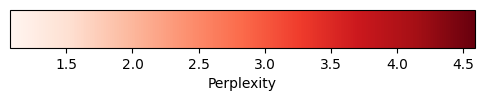

In [719]:
display_colored_sentences(filtered_tokens_p3_spk0, filtered_ppl_p3_spk0, tokenizer)

### Annotations

In [720]:
annotation_file = f"/u/sebono/conversational_dominance/data/processed/triadic-pilot/annotation_files/childs-joint-engagement-with-parent/aggregated_annotation_files.csv"

In [721]:
annotations = pd.read_csv(annotation_file)
annotations_dataset = annotations[annotations['uniq_vid_clip'].str.startswith(file_name)]
annotations_dataset.head()

,Unnamed: 0,Label-Name,NAN,Start-Timestamp,Start-Timestamp(sec),End-Timestamp,End-Timestamp(sec),Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
9256,0,p08-child (joint-engagement-wt-parent),NaN,00:00:00.000,0.0,00:00:05.000,5.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-0.0,NaN,NaN
9257,1,p08-child (joint-engagement-wt-parent),NaN,00:00:05.000,5.0,00:00:10.000,10.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-5.0,NaN,NaN
9258,2,p08-child (joint-engagement-wt-parent),NaN,00:00:10.000,10.0,00:00:15.000,15.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-10.0,NaN,NaN
9259,3,p08-child (joint-engagement-wt-parent),NaN,00:00:15.000,15.0,00:00:20.000,20.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-15.0,NaN,NaN
9260,4,p08-child (joint-engagement-wt-parent),NaN,00:00:20.000,20.0,00:00:25.000,25.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-20.0,NaN,NaN


In [722]:
conversation_dataset_file = f'/u/sebono/conversational_dominance/data/external/triadic-pilot/{file_name}_REV.csv'
conversation_dataset = pd.read_csv(conversation_dataset_file)
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.
...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?"
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.


In [723]:
assert len(matches) == len(conversation_dataset['content'])

In [724]:
conversation_dataset["tokens"] = [token.detach().numpy() for token in filtered_tokens_p1]
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content,tokens
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.,"[3966, 13, 575, 323, 13, 632, 338, 1621, 640, ..."
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.,"[18435, 13, 220]"
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.,"[15902, 13, 15902, 449, 26762, 13, 220]"
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...,"[314, 716, 407, 319, 8362, 3862, 4235, 13, 201..."
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.,"[16805, 13, 220]"
...,...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...,"[843, 3387, 1844, 262, 1621, 5526, 351, 534, 1..."
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?","[1439, 826, 11, 345, 3492, 284, 787, 534, 5526..."
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.,"[6952, 345, 13, 47843, 33847, 13, 220]"
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.,"[47843, 33847, 13, 220]"


In [725]:
import pandas as pd

df = conversation_dataset.copy()
df["start_time"] = pd.to_timedelta(df["timestamp"]).dt.total_seconds()
df["end_time"] = df["start_time"].shift(-1)
df.loc[df.index[-1], "end_time"] = df["start_time"].iloc[-1] + 1
df = df[["start_time", "end_time", "speaker", "content", "tokens"]]

In [809]:
import numpy as np
import pandas as pd
import torch
from collections import defaultdict

def assign_words_to_bins(df, bin_size=5.0):
    """
    Assigns tokens to time bins based on uniform spread over the utterance duration.
    Includes utterances with 0 duration. Ensures all bins from time 0 to max stop are represented.

    Args:
        df (pd.DataFrame): DataFrame with columns ['start_time', 'end_time', 'tokens']
        bin_size (float): Size of each time bin in seconds

    Returns:
        pd.DataFrame: each row is a bin with its start/end time, decoded words, token indices, and token count
    """
    bin_tok = defaultdict(list)
    bin_ppl = defaultdict(list)
    global_token_idx = 0

    for _, row in df.iterrows():
        start = row["start_time"]
        stop = row["end_time"]
        tokens = row["tokens"]

        if pd.isna(start) or pd.isna(stop) or tokens is None or len(tokens) == 0:
            continue

        duration = stop - start
        if duration < 0:
            continue

        # Handle 0-duration: treat as a very short utterance
        if duration == 0:
            duration = 1e-6

        # Token timing interpolation
        tok_times = np.linspace(start, stop, len(tokens) + 1)

        for i, token in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor((tok_end - 1e-6) / bin_size))  # avoid border collision

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[b].append(token)
                bin_ppl[b].append(global_token_idx + i)

        global_token_idx += len(tokens)

    # Build output DataFrame
    max_bin = int(np.ceil(df["end_time"].max() / bin_size))
    all_bins = list(range(max_bin + 1))

    bins_df = pd.DataFrame([
        {
            "time_bin": b,
            "start_time": b * bin_size,
            "end_time": (b + 1) * bin_size,
            "words": tokenizer.decode(torch.tensor(bin_tok[b]), skip_special_tokens=True),
            "ppl": bin_ppl[b],
            "tokens": torch.tensor(bin_tok[b]),
            "n_tok": len(bin_tok[b])
        }
        for b in all_bins
    ])

    return bins_df

In [810]:
bins_df = assign_words_to_bins(df, bin_size=5.0)

In [811]:
bins_df

,time_bin,start_time,end_time,words,ppl,tokens,n_tok
0,0,0.0,5.0,Oh. Yay. It's story,"[0, 1, 2, 3, 4, 5, 6, 7]","[tensor(3966), tensor(13), tensor(575), tensor...",8
1,1,5.0,10.0,story time. Hello. Hi. Hi Jibo.,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[tensor(1621), tensor(640), tensor(13), tensor...",14
2,2,10.0,15.0,I am not on Story Time mode. My camera will n...,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...","[tensor(314), tensor(716), tensor(407), tensor...",19
3,3,15.0,20.0,video recording. Okay. Let's get started. N...,"[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5...","[tensor(2008), tensor(8296), tensor(13), tenso...",18
4,4,20.0,25.0,"storybooks together. If you haven't already, ...","[56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 6...","[tensor(1621), tensor(12106), tensor(1978), te...",14
...,...,...,...,...,...,...,...
341,341,1705.0,1710.0,I will now stop recording to respect your pri...,"[4931, 4932, 4933, 4934, 4935, 4936, 4937, 493...","[tensor(314), tensor(481), tensor(783), tensor...",20
342,342,1710.0,1715.0,Bye bye. I will switch back to leisure mode...,"[4951, 4952, 4953, 4954, 4955, 4956, 4957, 495...","[tensor(220), tensor(47843), tensor(33847), te...",19
343,343,1715.0,1720.0,And please complete the story survey with you...,"[4970, 4971, 4972, 4973, 4974, 4975, 4976, 497...","[tensor(843), tensor(3387), tensor(1844), tens...",30
344,344,1720.0,1725.0,Bye bye...,"[5004, 5005, 5006]","[tensor(47843), tensor(33847), tensor(986)]",3


In [812]:
assert len(bins_df) == len(annotations_dataset)

In [813]:
combined_df = pd.concat([bins_df.reset_index(drop=True), annotations_dataset.iloc[:bins_df.shape[0]].reset_index(drop=True)], axis=1)
combined_df.iloc[25:]

,time_bin,start_time,end_time,words,ppl,tokens,n_tok,Unnamed: 0,Label-Name,NAN,...,Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
25,25,125.0,130.0,A B to the top of the coconut tree,"[316, 317, 318, 319, 320, 321, 322, 323, 324]","[tensor(317), tensor(347), tensor(284), tensor...",9,25,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-125.0,1.0,0.0
26,26,130.0,135.0,tree. Good job. What's next?,"[324, 325, 326, 327, 328, 329, 330, 331, 332, ...","[tensor(5509), tensor(13), tensor(220), tensor...",10,26,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-130.0,1.0,0.0
27,27,135.0,140.0,"? A... Chicka, chicka, boom, boom- Boom","[333, 334, 335, 336, 337, 338, 339, 340, 341, ...","[tensor(30), tensor(220), tensor(317), tensor(...",18,27,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-135.0,1.0,0.0
28,28,140.0,145.0,"Boom, boom. Here comes...","[350, 351, 352, 353, 354, 355, 356, 357, 358, ...","[tensor(31824), tensor(11), tensor(14166), ten...",10,28,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-140.0,1.0,0.0
29,29,145.0,150.0,H up the coconut tree. . What? ...,"[363, 364, 365, 366, 367, 368, 369, 370, 371, ...","[tensor(367), tensor(510), tensor(262), tensor...",14,29,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,1.0,Susanna/,1.0,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-145.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,341,1705.0,1710.0,I will now stop recording to respect your pri...,"[4931, 4932, 4933, 4934, 4935, 4936, 4937, 493...","[tensor(314), tensor(481), tensor(783), tensor...",20,341,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1705.0,NaN,NaN
342,342,1710.0,1715.0,Bye bye. I will switch back to leisure mode...,"[4951, 4952, 4953, 4954, 4955, 4956, 4957, 495...","[tensor(220), tensor(47843), tensor(33847), te...",19,342,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1710.0,NaN,NaN
343,343,1715.0,1720.0,And please complete the story survey with you...,"[4970, 4971, 4972, 4973, 4974, 4975, 4976, 497...","[tensor(843), tensor(3387), tensor(1844), tens...",30,343,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1715.0,NaN,NaN
344,344,1720.0,1725.0,Bye bye...,"[5004, 5005, 5006]","[tensor(47843), tensor(33847), tensor(986)]",3,344,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1720.0,NaN,NaN


In [814]:
import pandas as pd

def expand_multiple_ppl_by_token(bin_df, ppl_dict, annotation_cols=None):
    """
    Expands a bin-level DataFrame into token-level rows, adding multiple PPL values per token.

    Args:
        bin_df (pd.DataFrame): must contain 'ppl' as a list of token indices.
        ppl_dict (dict): dictionary of {name: List[float]}, e.g. {'ppl1': [...], 'ppl2': [...]}
        annotation_cols (List[str]): optional list of annotation columns to repeat per token.

    Returns:
        pd.DataFrame: one row per token with multiple ppl values and repeated annotations.
    """
    # Validate that all ppl lists have the same length
    lengths = [len(v) for v in ppl_dict.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All PPL arrays must have the same length.")

    records = []

    for _, row in bin_df.iterrows():
        token_ids = row["ppl"]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        for tok_id in token_ids:
            if tok_id >= lengths[0]:
                continue  # skip out-of-bounds

            record = {"token_id": tok_id}
            for name, ppl_values in ppl_dict.items():
                record[name] = ppl_values[tok_id]

            if annotation_cols:
                for col in annotation_cols:
                    record[col] = row.get(col, None)

            records.append(record)

    return pd.DataFrame(records)

In [815]:
cols = ['Rating_x', 'Rating_y','start_time','end_time']
ppl_dict = {'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_filtered_expanded = expand_multiple_ppl_by_token(combined_df, ppl_dict, annotation_cols=cols)

In [816]:
from sklearn.decomposition import PCA
all_data_filtered_expanded.ffill(inplace=True)
X = np.column_stack((all_data_filtered_expanded["p2"],all_data_filtered_expanded["p3"]))

In [817]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

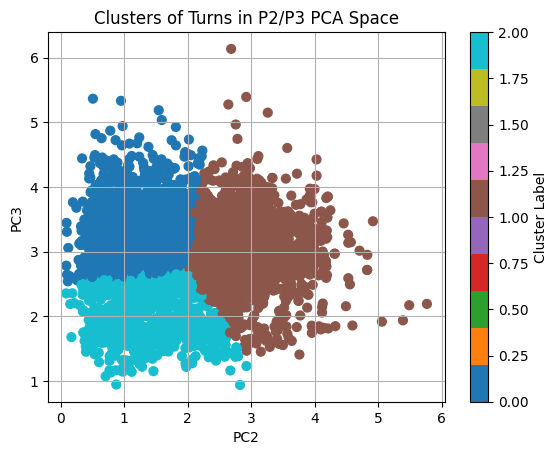

In [818]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [819]:
# AFTER
col_1 = ["p2","p3"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_filtered_expanded)

In [820]:
fig_corr

In [821]:
def average_ppl_per_turn(df, ppl_dict, idx_col='ppl', annotation_cols=None):
    """
    For each row in df, average values from ppl_dict at indices listed in df[idx_col].

    Args:
        df (pd.DataFrame): DataFrame with a column of token indices (e.g., 'ppl').
        ppl_dict (dict): Dictionary with name -> list of PPL values.
        idx_col (str): Column in df with list of indices per turn.
        annotation_cols (List[str]): Optional columns to carry forward.

    Returns:
        pd.DataFrame: Averaged PPL values per turn, optionally with annotations.
    """
    import numpy as np
    import pandas as pd

    records = []
    for _, row in df.iterrows():
        token_ids = row[idx_col]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        record = {}
        for name, ppl_values in ppl_dict.items():
            selected = [ppl_values[i] for i in token_ids if i < len(ppl_values)]
            record[f'{name}_avg'] = np.mean(selected) if selected else None
            record['tokens'] = token_ids
            record['tok_len'] = len(token_ids)

        if annotation_cols:
            for col in annotation_cols:
                record[col] = row.get(col, None)

        records.append(record)

    return pd.DataFrame(records)

In [822]:
all_data_filtered

,p1,p2,p3
0,6.108383,5.767464,2.193449
1,3.501551,5.389812,1.939209
2,6.080739,5.488516,2.173117
3,2.046488,5.058262,1.918387
4,0.880916,4.594112,1.859408
...,...,...,...
5002,0.181420,0.358916,2.760998
5003,0.403909,0.361164,2.023626
5004,2.167233,0.595020,3.692395
5005,0.084459,0.522660,3.201223


In [831]:
cols = ['Rating_x', 'Rating_y','words','start_time','end_time', 'tokens']
ppl_dict = {'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_filtered_expanded = average_ppl_per_turn(combined_df, ppl_dict, annotation_cols=cols)

In [832]:
all_data_filtered_expanded

,p2_avg,tokens,tok_len,p3_avg,Rating_x,Rating_y,words,start_time,end_time
0,4.979189,"[tensor(3966), tensor(13), tensor(575), tensor...",8,2.248489,NaN,NaN,Oh. Yay. It's story,0.0,5.0
1,2.849399,"[tensor(1621), tensor(640), tensor(13), tensor...",14,2.038649,NaN,NaN,story time. Hello. Hi. Hi Jibo.,5.0,10.0
2,2.633813,"[tensor(314), tensor(716), tensor(407), tensor...",19,2.510792,NaN,NaN,I am not on Story Time mode. My camera will n...,10.0,15.0
3,1.697103,"[tensor(2008), tensor(8296), tensor(13), tenso...",18,2.296145,NaN,NaN,video recording. Okay. Let's get started. N...,15.0,20.0
4,2.479838,"[tensor(1621), tensor(12106), tensor(1978), te...",14,2.489015,NaN,NaN,"storybooks together. If you haven't already, ...",20.0,25.0
...,...,...,...,...,...,...,...,...,...
340,2.153705,"[tensor(338), tensor(6246), tensor(13), tensor...",17,2.713342,NaN,NaN,'s session. I had so much fun. Say thank you ...,1700.0,1705.0
341,2.638505,"[tensor(314), tensor(481), tensor(783), tensor...",20,3.025231,NaN,NaN,I will now stop recording to respect your pri...,1705.0,1710.0
342,1.630726,"[tensor(220), tensor(47843), tensor(33847), te...",19,2.683373,NaN,NaN,Bye bye. I will switch back to leisure mode...,1710.0,1715.0
343,1.951112,"[tensor(843), tensor(3387), tensor(1844), tens...",30,2.815784,NaN,NaN,And please complete the story survey with you...,1715.0,1720.0


In [833]:
sum(all_data_filtered_expanded['Rating_x']==1), sum(all_data_filtered_expanded['Rating_x']==0), sum(all_data_filtered_expanded['Rating_x']==2), sum(all_data_filtered_expanded['Rating_x']==-2), sum(all_data_filtered_expanded['Rating_x']==-1)

(168, 83, 6, 0, 5)

In [834]:
from utils import correlation_heatmap

In [835]:
# AFTER
col_1 = ["p2_avg","p3_avg"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_filtered_expanded.iloc[10:])

In [836]:
fig_corr

In [864]:
fig_p

In [838]:
all_data_filtered_expanded

,p2_avg,tokens,tok_len,p3_avg,Rating_x,Rating_y,words,start_time,end_time
0,4.979189,"[tensor(3966), tensor(13), tensor(575), tensor...",8,2.248489,NaN,NaN,Oh. Yay. It's story,0.0,5.0
1,2.849399,"[tensor(1621), tensor(640), tensor(13), tensor...",14,2.038649,NaN,NaN,story time. Hello. Hi. Hi Jibo.,5.0,10.0
2,2.633813,"[tensor(314), tensor(716), tensor(407), tensor...",19,2.510792,NaN,NaN,I am not on Story Time mode. My camera will n...,10.0,15.0
3,1.697103,"[tensor(2008), tensor(8296), tensor(13), tenso...",18,2.296145,NaN,NaN,video recording. Okay. Let's get started. N...,15.0,20.0
4,2.479838,"[tensor(1621), tensor(12106), tensor(1978), te...",14,2.489015,NaN,NaN,"storybooks together. If you haven't already, ...",20.0,25.0
...,...,...,...,...,...,...,...,...,...
340,2.153705,"[tensor(338), tensor(6246), tensor(13), tensor...",17,2.713342,NaN,NaN,'s session. I had so much fun. Say thank you ...,1700.0,1705.0
341,2.638505,"[tensor(314), tensor(481), tensor(783), tensor...",20,3.025231,NaN,NaN,I will now stop recording to respect your pri...,1705.0,1710.0
342,1.630726,"[tensor(220), tensor(47843), tensor(33847), te...",19,2.683373,NaN,NaN,Bye bye. I will switch back to leisure mode...,1710.0,1715.0
343,1.951112,"[tensor(843), tensor(3387), tensor(1844), tens...",30,2.815784,NaN,NaN,And please complete the story survey with you...,1715.0,1720.0


In [839]:
repeated_p2_list = sum([[p2] * l for p2, l in zip(all_data_filtered_expanded['p2_avg'], all_data_filtered_expanded['tok_len'])], [])

In [844]:
repeated_p3_list = sum([[p3] * l for p3, l in zip(all_data_filtered_expanded['p3_avg'], all_data_filtered_expanded['tok_len'])], [])

In [840]:
assert all_data_filtered_expanded["tok_len"].sum() == len(repeated_p2_list)

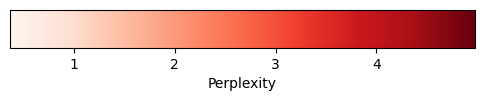

In [843]:
display_colored_sentences(list(all_data_filtered_expanded['tokens']), repeated_p2_list, tokenizer)

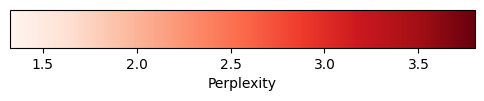

In [845]:
display_colored_sentences(list(all_data_filtered_expanded['tokens']), repeated_p3_list, tokenizer)

### Clusters

In [847]:
all_data_filtered_expanded["p2_avg"]

0      4.979189
1      2.849399
2      2.633813
3      1.697103
4      2.479838
         ...   
340    2.153705
341    2.638505
342    1.630726
343    1.951112
344    0.740833
Name: p2_avg, Length: 345, dtype: float64

In [848]:
from sklearn.decomposition import PCA
all_data_filtered.ffill(inplace=True)
X = np.column_stack((all_data_filtered_expanded["p2_avg"],all_data_filtered_expanded["p3_avg"]))

In [849]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

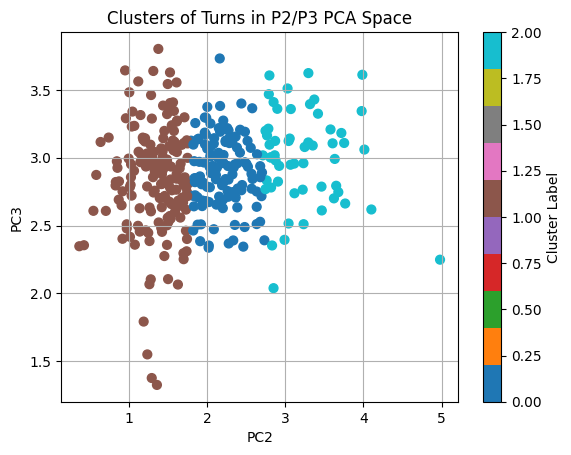

In [850]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [863]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0][:10]
    print(all_data_filtered_expanded.iloc[indices]['words'].to_numpy())



--- Cluster 0 ---
[' illustrated by Lewis Elhart. Ready? A'
 "'ll meet you at the top of the coconut"
 ' coconut tree..  Can you tell me what-'
 '-   Oh Jibo has a question. Jibo said tell him what letters.  Can you tell me what letters there are in'
 '.  You want to have Jibo, hey J' ' A B to the top of the coconut tree'
 " tree.  Good job. What's next?" ' H up the coconut tree.  .  What? ...'
 '.  How many letters are there now?  How many letters? Can you count the'
 ' the letters?  B. E. E. F. A. ']

--- Cluster 1 ---
[" A told B and B told C I'll"
 ' in the picture?  What letters are in the picture?  A.  A. Yeah. What else?  B. '
 ' B.  C.  C. Good job. A, B, C.  I like that. '
 ' Awe thanks. Good job. Oh thank you.'
 '?  A...  Chicka, chicka, boom, boom-   Boom'
 ' Boom, boom.   Here comes... ' '? Will there be enough room?  The other'
 ' other.   Will there be enough room'
 '? Room. Can you say room?  Room.  Room'
 ", four, five.  Five, Jibo. That's right, right? Say five.  Five

### Finding Signal

In [852]:
from utils import compute_dominance_per_spk, compute_significance

In [853]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data_filtered["p2"], filtered_tokens_p1, matches, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data_filtered["p3"], filtered_tokens_p1, matches, tokenizer)

In [854]:
all_data_filtered_expanded

,p2_avg,tokens,tok_len,p3_avg,Rating_x,Rating_y,words,start_time,end_time
0,4.979189,"[tensor(3966), tensor(13), tensor(575), tensor...",8,2.248489,NaN,NaN,Oh. Yay. It's story,0.0,5.0
1,2.849399,"[tensor(1621), tensor(640), tensor(13), tensor...",14,2.038649,NaN,NaN,story time. Hello. Hi. Hi Jibo.,5.0,10.0
2,2.633813,"[tensor(314), tensor(716), tensor(407), tensor...",19,2.510792,NaN,NaN,I am not on Story Time mode. My camera will n...,10.0,15.0
3,1.697103,"[tensor(2008), tensor(8296), tensor(13), tenso...",18,2.296145,NaN,NaN,video recording. Okay. Let's get started. N...,15.0,20.0
4,2.479838,"[tensor(1621), tensor(12106), tensor(1978), te...",14,2.489015,NaN,NaN,"storybooks together. If you haven't already, ...",20.0,25.0
...,...,...,...,...,...,...,...,...,...
340,2.153705,"[tensor(338), tensor(6246), tensor(13), tensor...",17,2.713342,NaN,NaN,'s session. I had so much fun. Say thank you ...,1700.0,1705.0
341,2.638505,"[tensor(314), tensor(481), tensor(783), tensor...",20,3.025231,NaN,NaN,I will now stop recording to respect your pri...,1705.0,1710.0
342,1.630726,"[tensor(220), tensor(47843), tensor(33847), te...",19,2.683373,NaN,NaN,Bye bye. I will switch back to leisure mode...,1710.0,1715.0
343,1.951112,"[tensor(843), tensor(3387), tensor(1844), tens...",30,2.815784,NaN,NaN,And please complete the story survey with you...,1715.0,1720.0


In [855]:
from scipy.stats import spearmanr
import pandas as pd

cols = ['Rating_x','Rating_y']
# Perform correlation
stat, pval = spearmanr(all_data_filtered_expanded['p3_avg'], all_data_filtered_expanded[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
1,Rating_y,-0.306982,4.018463e-07
0,Rating_x,-0.291922,1.526766e-06


In [856]:
X = all_data_filtered_expanded[cols].fillna(0)
y = all_data_filtered_expanded['p3_avg']

In [857]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

    feature  importance
1  Rating_y    0.776572
0  Rating_x    0.223428


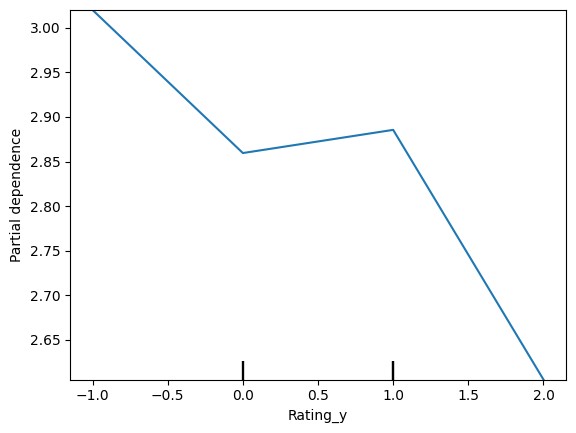

In [858]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X, ['Rating_y'])
plt.show()


In [859]:
from sklearn.model_selection import train_test_split
# Features and target
all_data_filtered_expanded.dropna(inplace=True)
X = all_data_filtered_expanded[cols]
y = all_data_filtered_expanded["p3_avg"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

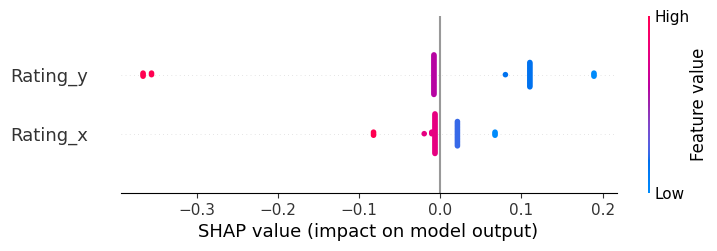

In [860]:
import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)